In [1]:
# Add target col

import pandas as pd
import nba_api_module as nbpim

df_input = pd.read_csv("data/ml_ready_2024_25.csv")

# Drop star injury
df_input.drop(columns=['home_missing_starters', 'away_missing_starters'], inplace=True)


gid = f"00{df_input.loc[0, "game_id"]}"

season_log = nbpim.get_season_game_log("2024-25")
season_log_home = season_log[season_log['MATCHUP'].str.contains(' vs. ')]
season_log_home['is_home_win'] = season_log_home['WL'].apply(lambda x: 1 if x == 'W' else 0)
season_log_home.rename(columns={'GAME_ID': 'game_id'}, inplace=True)
season_log_home.game_id = season_log_home.game_id.astype(int)

df_input = pd.merge(df_input, season_log_home[['game_id', 'is_home_win']],
                    on="game_id", how="left")

print(df_input.sample(5))
print(df_input.columns)

      game_id  home_ORtg  away_ORtg  home_DRtg  away_DRtg  home_NET_rtg  \
224  22400225  95.847321  92.124892  95.180133  86.520178      0.667188   
338  22400339  86.110490  88.250746  90.540750  93.810078     -4.430260   
89   22400090  85.895773  99.700672  96.519184  90.957111    -10.623411   
19   22400020  93.110706  91.175603  92.501856  88.387046      0.608851   
220  22400221  95.035823  87.598516  84.610709  94.612734     10.425115   

     away_NET_rtg   home_PACE   away_PACE  home_TS%  ...  home_rest_days  \
224      5.604714  118.176731  133.815926  0.592093  ...               2   
338     -5.559331  126.813818  127.246852  0.555231  ...               5   
89       8.743561  126.380556  123.053519  0.544800  ...               5   
19       2.788557  125.422545  122.311071  0.577500  ...               4   
220     -7.014219  123.988333  126.237091  0.582650  ...               1   

     home_recent_form10  home_recent_form5  home_recent_form3  \
224                 0.8    

C:\Users\Adam\AppData\Local\Temp\ipykernel_12280\1038124081.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  season_log_home['is_home_win'] = season_log_home['WL'].apply(lambda x: 1 if x == 'W' else 0)
C:\Users\Adam\AppData\Local\Temp\ipykernel_12280\1038124081.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  season_log_home.rename(columns={'GAME_ID': 'game_id'}, inplace=True)
C:\Users\Adam\AppData\Local\Temp\ipykernel_12280\1038124081.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_ind

Új differenciális features hozzáadva. Új shape: (550, 62)

Új feature-ök száma: 20

=== ERŐSEN KORRELÁLÓ FEATURE PÁROK (|corr| > 0.85) ===

     Feature 1      Feature 2  Correlation
home_rest_days away_rest_days     0.999458
       TS_diff       EFG_diff     0.992266
      home_TS%      home_EFG%     0.991397
      away_TS%      away_EFG%     0.990996
     ORtg_diff        TS_diff     0.954334
     home_ORtg       home_TS%     0.954181
     ORtg_diff       EFG_diff     0.951286
     home_ORtg      home_EFG%     0.951124
     away_ORtg       away_TS%     0.948221
     away_ORtg      away_EFG%     0.946333

=== TOP 15 FEATURE CORRELATION A TARGET-TEL ===

NET_rtg_diff           0.421425
recent_form10_diff     0.323449
away_NET_rtg           0.319516
recent_form5_diff      0.307741
home_NET_rtg           0.306267
turnover_diff          0.282006
ORtg_diff              0.278071
EFG_diff               0.270192
TS_diff                0.267419
recent_form3_diff      0.263959
home_recent_form1

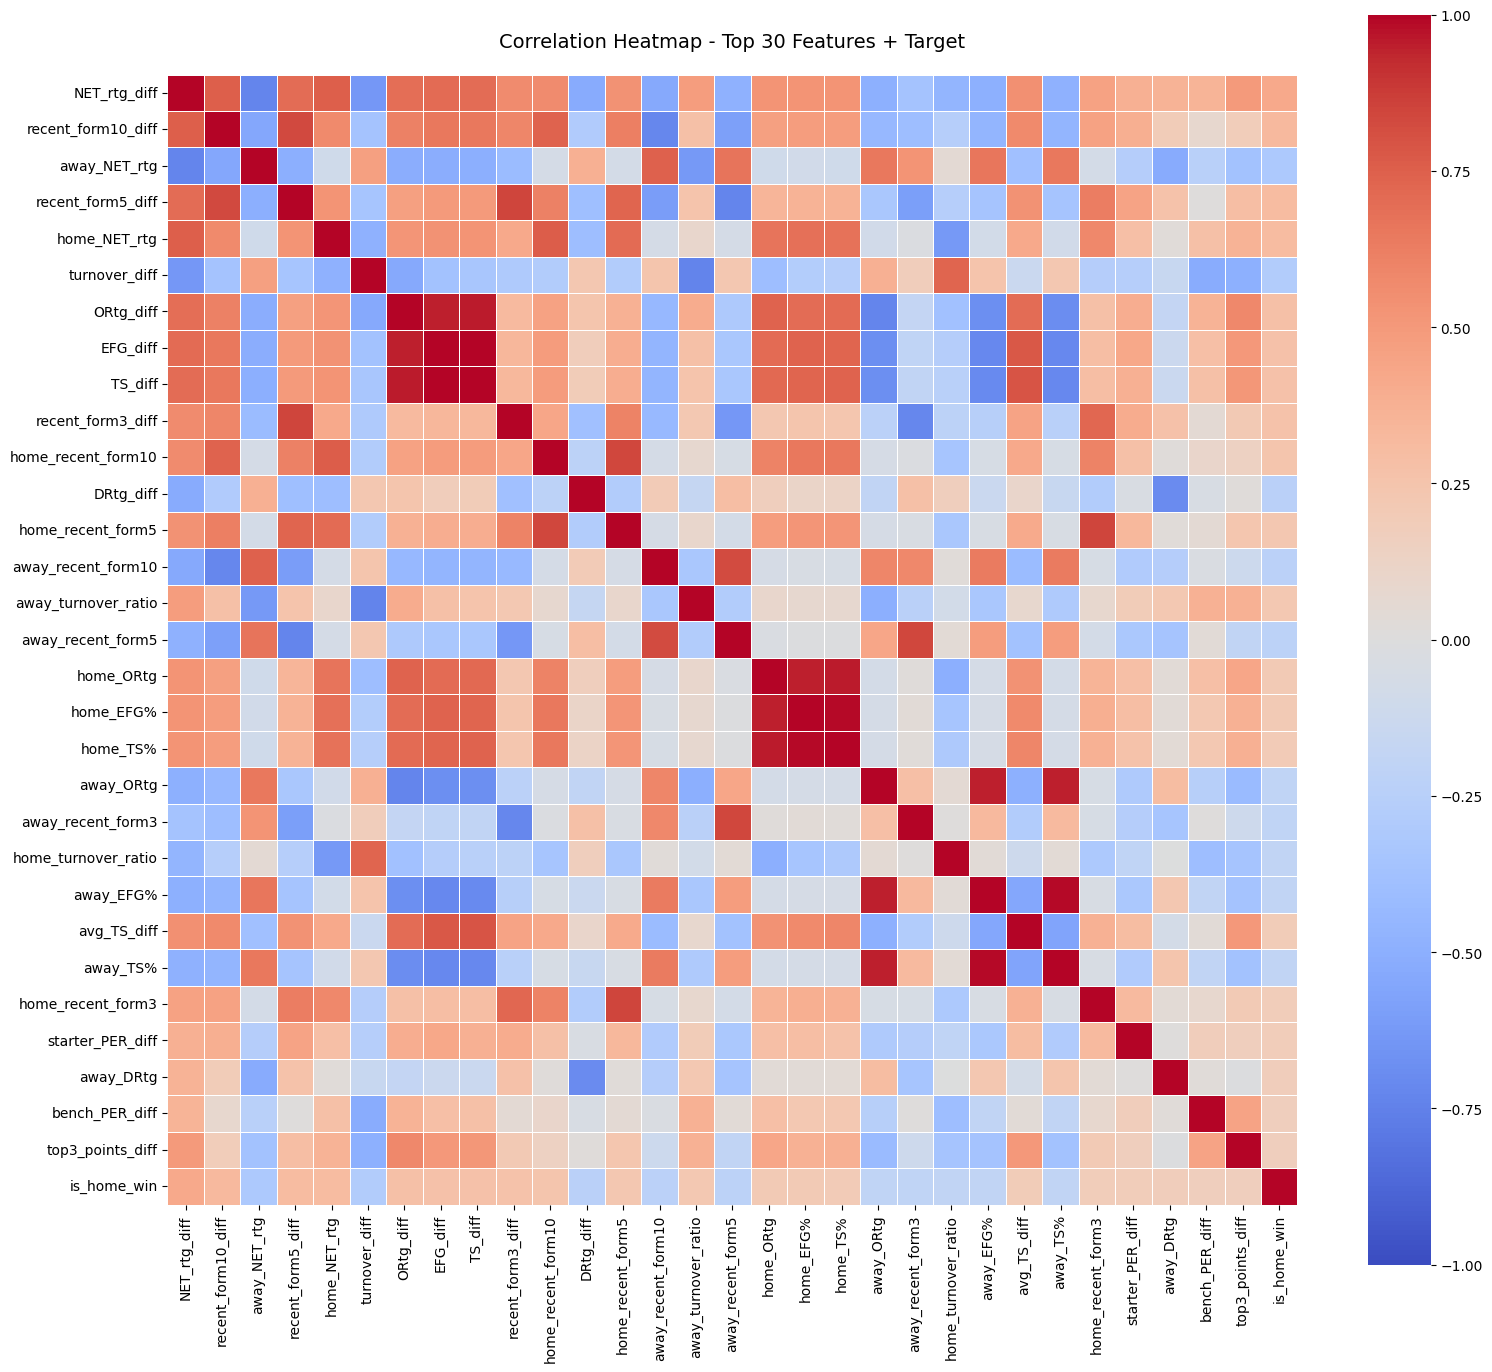


=== AJÁNLÁS: REDUNDÁNS FEATURES ELTÁVOLÍTÁSA ===

Javasolt eltávolítandó features (7 db):
  - away_EFG%
  - TS_diff
  - home_TS%
  - away_TS%
  - home_rest_days
  - EFG_diff
  - home_EFG%

=== EREDMÉNY ===
Eredeti feature-ök száma: 42
Új differenciális features: 20
Összes feature most: 62

Használd a 'df' dataframe-et a továbbiakban a bővített feature-ökkel!


In [2]:
# Feature engineering

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------------------------------------------------
# 1) DIFFERENCIÁLIS FEATURES HOZZÁADÁSA
# -------------------------------------------------------------------------

df = df_input.copy()

# Offensive/Defensive Rating különbségek
df['ORtg_diff'] = df['home_ORtg'] - df['away_ORtg']
df['DRtg_diff'] = df['home_DRtg'] - df['away_DRtg']
df['NET_rtg_diff'] = df['home_NET_rtg'] - df['away_NET_rtg']

# Pace különbség
df['PACE_diff'] = df['home_PACE'] - df['away_PACE']

# Hatékonyság különbségek
df['TS_diff'] = df['home_TS%'] - df['away_TS%']
df['EFG_diff'] = df['home_EFG%'] - df['away_EFG%']
df['AST_ratio_diff'] = df['home_AST_ratio'] - df['away_AST_ratio']
df['OREB_diff'] = df['home_OREB%'] - df['away_OREB%']
df['turnover_diff'] = df['home_turnover_ratio'] - df['away_turnover_ratio']

# Játékos minőség különbségek
df['starter_PER_diff'] = df['home_starter_avg_PER'] - df['away_starter_avg_PER']
df['bench_PER_diff'] = df['home_bench_avg_PER'] - df['away_bench_avg_PER']
df['star_usage_diff'] = df['home_star_usage'] - df['away_star_usage']
df['avg_TS_diff'] = df['home_avg_TS'] - df['away_avg_TS']
df['top3_points_diff'] = df['home_top3_points_avg'] - df['away_top3_points_avg']

# Pihenés és forma különbségek
df['rest_days_diff'] = df['home_rest_days'] - df['away_rest_days']
df['recent_form10_diff'] = df['home_recent_form10'] - df['away_recent_form10']
df['recent_form5_diff'] = df['home_recent_form5'] - df['away_recent_form5']
df['recent_form3_diff'] = df['home_recent_form3'] - df['away_recent_form3']

# Sérülés különbség
df['injury_count_diff'] = df['home_injury_count'] - df['away_injury_count']

# Back-to-back advantage (1 ha csak away, -1 ha csak home, 0 ha mindkettő vagy egyik sem)
df['b2b_advantage'] = df['away_is_back_to_back'].astype(int) - df['home_is_back_to_back'].astype(int)

print(f"Új differenciális features hozzáadva. Új shape: {df.shape}")
print(f"\nÚj feature-ök száma: {len([col for col in df.columns if 'diff' in col or 'advantage' in col])}")

# -------------------------------------------------------------------------
# 2) CORRELATION VIZSGÁLAT - CSAK NUMERIKUS FEATURE-ÖK
# -------------------------------------------------------------------------

# Exclude target és ID
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'is_home_win' in numeric_cols:
    numeric_cols.remove('is_home_win')
if 'game_id' in numeric_cols:
    numeric_cols.remove('game_id')

# Correlation matrix
corr_matrix = df[numeric_cols].corr()

# Erősen korreláló párok keresése (|corr| > 0.85, de nem önmagával)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.85:
            high_corr_pairs.append({
                'Feature 1': corr_matrix.columns[i],
                'Feature 2': corr_matrix.columns[j],
                'Correlation': corr_matrix.iloc[i, j]
            })

print(f"\n=== ERŐSEN KORRELÁLÓ FEATURE PÁROK (|corr| > 0.85) ===\n")
if high_corr_pairs:
    corr_df = pd.DataFrame(high_corr_pairs).sort_values('Correlation', 
                                                          key=abs, 
                                                          ascending=False)
    print(corr_df.to_string(index=False))
else:
    print("Nincs erősen korreláló feature pár (|corr| > 0.85)")

# -------------------------------------------------------------------------
# 3) CORRELATION HEATMAP (TOP 30 FEATURE TARGET-TEL)
# -------------------------------------------------------------------------

# Correlation a target változóval
target_corr = df[numeric_cols].corrwith(df['is_home_win']).abs().sort_values(ascending=False)

print(f"\n=== TOP 15 FEATURE CORRELATION A TARGET-TEL ===\n")
print(target_corr.head(15))

# Vizualizáció: top 30 feature heatmap
top_features = target_corr.head(30).index.tolist()
top_features.append('is_home_win')

plt.figure(figsize=(16, 14))
sns.heatmap(df[top_features].corr(), 
            annot=False, 
            cmap='coolwarm', 
            center=0,
            vmin=-1, vmax=1,
            square=True,
            linewidths=0.5)
plt.title('Correlation Heatmap - Top 30 Features + Target', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------------
# 4) AJÁNLÁSOK REDUNDÁNS FEATURES-ÖK ELTÁVOLÍTÁSÁRA
# -------------------------------------------------------------------------

print(f"\n=== AJÁNLÁS: REDUNDÁNS FEATURES ELTÁVOLÍTÁSA ===\n")

features_to_remove = []
for pair in high_corr_pairs:
    feat1, feat2 = pair['Feature 1'], pair['Feature 2']
    # Tartsd meg azt amelyik jobban korrelál a target-tel
    corr1 = abs(df[feat1].corr(df['is_home_win']))
    corr2 = abs(df[feat2].corr(df['is_home_win']))
    
    if corr1 > corr2:
        features_to_remove.append(feat2)
    else:
        features_to_remove.append(feat1)

features_to_remove = list(set(features_to_remove))

if features_to_remove:
    print(f"Javasolt eltávolítandó features ({len(features_to_remove)} db):")
    for feat in features_to_remove:
        print(f"  - {feat}")
else:
    print("Nincs javasolt eltávolítandó feature.")

# -------------------------------------------------------------------------
# 5) UPDATED DATAFRAME EXPORT
# -------------------------------------------------------------------------

print(f"\n=== EREDMÉNY ===")
print(f"Eredeti feature-ök száma: {len(df_input.columns)}")
print(f"Új differenciális features: {len([col for col in df.columns if 'diff' in col or 'advantage' in col])}")
print(f"Összes feature most: {len(df.columns)}")
print(f"\nHasználd a 'df' dataframe-et a továbbiakban a bővített feature-ökkel!")

# Használható változó
df_enhanced = df.copy()

Dataset méret odds-szal: (549, 67)
Odds hiányzó értékek: 21
Features száma: 60

=== PCA VARIANCE ANALÍZIS ===
95% variance: 22/60 komponens
90% variance: 17/60 komponens

=== MODELLEK KIÉRTÉKELÉSE (ML + BETTING) ===

--- Standard Features ---

Futtatás: Logistic Regression...
Futtatás: Random Forest...
Futtatás: Gradient Boosting...
Futtatás: XGBoost (Tuned)...


c:\Users\Adam\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:29:37] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Adam\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:29:37] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Adam\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:29:37] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- PCA Features (90% variance) ---

Futtatás: Logistic Regression + PCA...
Futtatás: Random Forest + PCA...
Futtatás: XGBoost (Tuned) + PCA...


c:\Users\Adam\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:29:39] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Adam\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:29:39] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Adam\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:29:39] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



=== ML METRICS ===

                           Accuracy_mean  Accuracy_std  AUC_mean   AUC_std  LogLoss_mean  LogLoss_std
Random Forest + PCA             0.654434      0.049876  0.708051  0.031901      0.629468     0.039002
XGBoost (Tuned) + PCA           0.648318      0.011442  0.693340  0.026265      0.673737     0.046045
Logistic Regression + PCA       0.629969      0.026307  0.683587  0.029332      0.656921     0.036520
Logistic Regression             0.623853      0.014982  0.683322  0.015123      0.674541     0.020838
Random Forest                   0.642202      0.059456  0.682161  0.024942      0.654363     0.029713
XGBoost (Tuned)                 0.636086      0.037703  0.675904  0.013831      0.699955     0.036876
Gradient Boosting               0.611621      0.036951  0.660189  0.018793      0.767179     0.056118

=== BETTING METRICS ===

                           Total_Bets  Total_Profit     ROI_%  Hit_Rate_%  EV_per_Bet  Max_Drawdown
XGBoost (Tuned) + PCA           327.0

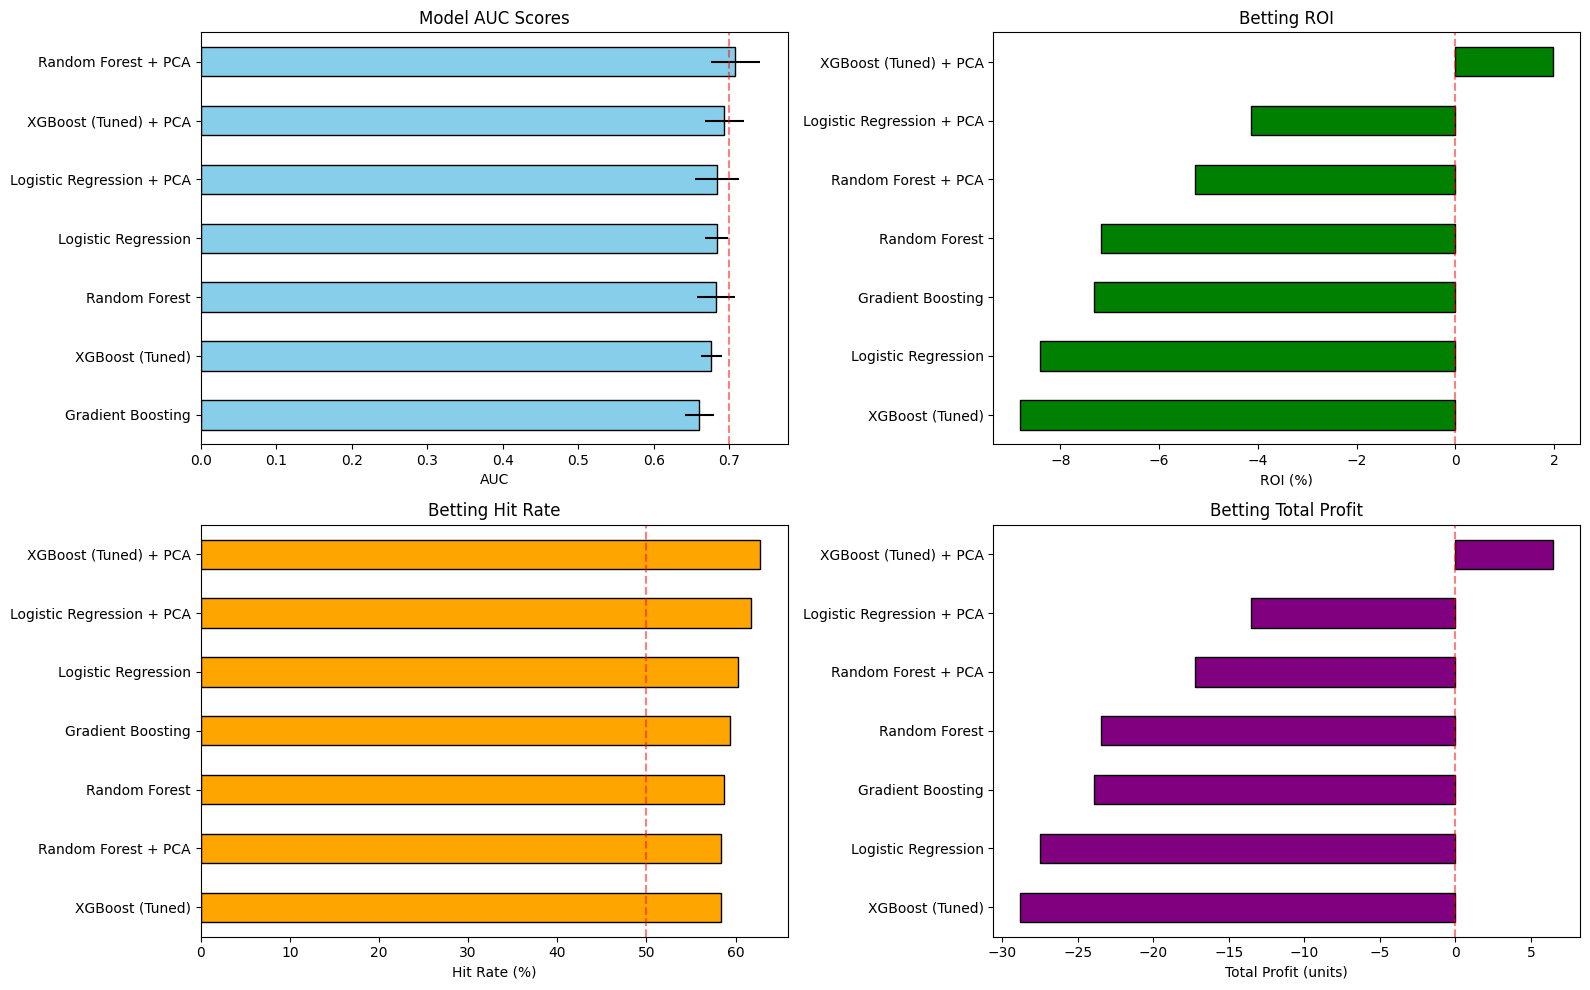

In [11]:
# ML teszt

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss
import matplotlib.pyplot as plt

# -------------------------------------------------------------------------
# 1) ADATOK ELŐKÉSZÍTÉSE + ODDS MERGE
# -------------------------------------------------------------------------

df = df_enhanced.copy()
df.dropna(subset=["is_home_win"], inplace=True)

# Odds merge (feltételezzük hogy odds df-ben van GAME_ID, odds_home, odds_away)
odds = pd.read_csv("data/game_odds_2024_25.csv")
df = df.merge(odds[['GAME_ID', 'odds_home', 'odds_away']], 
              left_on='game_id', right_on='GAME_ID', how='left')
df.drop(columns=['GAME_ID'], inplace=True)

# Implied probabilities számítása
df['implied_prob_home'] = 1 / df['odds_home']
df['implied_prob_away'] = 1 / df['odds_away']

# Margin (bookmaker edge)
df['book_margin'] = df['implied_prob_home'] + df['implied_prob_away'] - 1

print(f"Dataset méret odds-szal: {df.shape}")
print(f"Odds hiányzó értékek: {df['odds_home'].isna().sum()}")

# Célváltozó
y = df["is_home_win"]

# Features (game_id, odds és target nélkül)
feature_cols = [col for col in df.columns if col not in 
                ['is_home_win', 'game_id', 'odds_home', 'odds_away', 
                 'implied_prob_home', 'implied_prob_away', 'book_margin']]
X = df[feature_cols]

print(f"Features száma: {X.shape[1]}")

# -------------------------------------------------------------------------
# 2) PCA VIZSGÁLAT
# -------------------------------------------------------------------------

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_full = PCA()
pca_full.fit(X_scaled)

cumsum_variance = np.cumsum(pca_full.explained_variance_ratio_)
n_components_95 = np.argmax(cumsum_variance >= 0.95) + 1
n_components_90 = np.argmax(cumsum_variance >= 0.90) + 1

print(f"\n=== PCA VARIANCE ANALÍZIS ===")
print(f"95% variance: {n_components_95}/{X.shape[1]} komponens")
print(f"90% variance: {n_components_90}/{X.shape[1]} komponens")

# -------------------------------------------------------------------------
# 3) TIME-SERIES CV + BETTING EVALUATION
# -------------------------------------------------------------------------

def time_series_cv_split(X, y, n_splits=5, test_size=0.2):
    n_samples = len(X)
    test_size_samples = int(n_samples * test_size)
    step = test_size_samples
    
    splits = []
    for i in range(n_splits):
        test_end = n_samples - (n_splits - 1 - i) * step
        test_start = test_end - test_size_samples
        train_end = test_start
        
        if train_end < int(n_samples * 0.3):
            continue
            
        train_idx = np.arange(0, train_end)
        test_idx = np.arange(test_start, test_end)
        splits.append((train_idx, test_idx))
    
    return splits

def calculate_betting_metrics(y_true, pred_proba, odds_home, odds_away, 
                               threshold=0.4, unit_stake=1.0):
    """
    Betting szimuláció metrikákkal
    
    Args:
        threshold: Minimális predicted probability betting-hez
        unit_stake: Egységnyi tét (default 1.0)
    """
    bets = []
    cumulative_profit = 0
    peak_balance = 0
    max_drawdown = 0
    
    for i in range(len(y_true)):
        pred_home_prob = pred_proba[i]
        pred_away_prob = 1 - pred_home_prob
        
        actual_outcome = y_true.iloc[i]
        home_odds = odds_home.iloc[i]
        away_odds = odds_away.iloc[i]
        
        # Bet decision
        bet_placed = False
        bet_on_home = False
        stake = 0
        profit = 0
        
        # Bet on HOME if model confidence > threshold
        if pred_home_prob >= threshold:
            bet_placed = True
            bet_on_home = True
            stake = unit_stake
            
            if actual_outcome == 1:  # Home wins
                profit = stake * (home_odds - 1)
            else:
                profit = -stake
        
        # Bet on AWAY if model confidence > threshold
        elif pred_away_prob >= threshold:
            bet_placed = True
            bet_on_home = False
            stake = unit_stake
            
            if actual_outcome == 0:  # Away wins
                profit = stake * (away_odds - 1)
            else:
                profit = -stake
        
        if bet_placed:
            cumulative_profit += profit
            bets.append({
                'bet_on_home': bet_on_home,
                'stake': stake,
                'profit': profit,
                'cumulative': cumulative_profit,
                'odds': home_odds if bet_on_home else away_odds,
                'won': profit > 0
            })
            
            # Drawdown calculation
            if cumulative_profit > peak_balance:
                peak_balance = cumulative_profit
            
            drawdown = peak_balance - cumulative_profit
            if drawdown > max_drawdown:
                max_drawdown = drawdown
    
    if len(bets) == 0:
        return {
            'total_bets': 0,
            'total_profit': 0,
            'roi': 0,
            'hit_rate': 0,
            'avg_odds': 0,
            'max_drawdown': 0,
            'ev_per_bet': 0
        }
    
    bets_df = pd.DataFrame(bets)
    total_stake = bets_df['stake'].sum()
    total_profit = bets_df['profit'].sum()
    
    return {
        'total_bets': len(bets),
        'total_profit': total_profit,
        'roi': (total_profit / total_stake * 100) if total_stake > 0 else 0,
        'hit_rate': (bets_df['won'].sum() / len(bets) * 100),
        'avg_odds': bets_df['odds'].mean(),
        'max_drawdown': max_drawdown,
        'ev_per_bet': total_profit / len(bets),
        'bets_details': bets_df
    }

def evaluate_model_cv(model, X, y, df_full, cv_splits, use_pca=False, n_components=None):
    """
    Modell kiértékelése ML és Betting metrikákkal
    """
    # ML metrics
    accuracies = []
    aucs = []
    log_losses = []
    
    # Betting metrics
    all_betting_metrics = []
    
    for train_idx, test_idx in cv_splits:
        X_train_fold = X[train_idx]
        X_test_fold = X[test_idx]
        y_train_fold = y.iloc[train_idx]
        y_test_fold = y.iloc[test_idx]
        
        # Odds for test fold
        odds_home_test = df_full['odds_home'].iloc[test_idx]
        odds_away_test = df_full['odds_away'].iloc[test_idx]
        
        # Scaling
        scaler_fold = StandardScaler()
        X_train_scaled = scaler_fold.fit_transform(X_train_fold)
        X_test_scaled = scaler_fold.transform(X_test_fold)
        
        # PCA if needed
        if use_pca and n_components:
            pca = PCA(n_components=n_components)
            X_train_final = pca.fit_transform(X_train_scaled)
            X_test_final = pca.transform(X_test_scaled)
        else:
            if "Logistic" in str(type(model).__name__):
                X_train_final = X_train_scaled
                X_test_final = X_test_scaled
            else:
                X_train_final = X_train_fold
                X_test_final = X_test_fold
        
        # Training
        model.fit(X_train_final, y_train_fold)
        
        # Prediction
        pred_proba = model.predict_proba(X_test_final)[:, 1]
        preds = (pred_proba > 0.5).astype(int)
        
        # ML Metrics
        accuracies.append(accuracy_score(y_test_fold, preds))
        aucs.append(roc_auc_score(y_test_fold, pred_proba))
        log_losses.append(log_loss(y_test_fold, pred_proba))
        
        # Betting Metrics
        betting_metrics = calculate_betting_metrics(
            y_test_fold, pred_proba, odds_home_test, odds_away_test
        )
        all_betting_metrics.append(betting_metrics)
    
    # Aggregate betting metrics
    total_bets = sum([m['total_bets'] for m in all_betting_metrics])
    total_profit = sum([m['total_profit'] for m in all_betting_metrics])
    
    if total_bets > 0:
        avg_roi = np.mean([m['roi'] for m in all_betting_metrics if m['total_bets'] > 0])
        avg_hit_rate = np.mean([m['hit_rate'] for m in all_betting_metrics if m['total_bets'] > 0])
        avg_ev = np.mean([m['ev_per_bet'] for m in all_betting_metrics if m['total_bets'] > 0])
        max_dd = np.max([m['max_drawdown'] for m in all_betting_metrics])
    else:
        avg_roi = avg_hit_rate = avg_ev = max_dd = 0
    
    return {
        # ML Metrics
        "Accuracy_mean": np.mean(accuracies),
        "Accuracy_std": np.std(accuracies),
        "AUC_mean": np.mean(aucs),
        "AUC_std": np.std(aucs),
        "LogLoss_mean": np.mean(log_losses),
        "LogLoss_std": np.std(log_losses),
        
        # Betting Metrics
        "Total_Bets": total_bets,
        "Total_Profit": total_profit,
        "ROI_%": avg_roi,
        "Hit_Rate_%": avg_hit_rate,
        "EV_per_Bet": avg_ev,
        "Max_Drawdown": max_dd
    }

# -------------------------------------------------------------------------
# 4) MODELLEK
# -------------------------------------------------------------------------

xgb_tuned = XGBClassifier(
    n_estimators=200, learning_rate=0.05, max_depth=4,
    min_child_weight=5, gamma=1.0, subsample=0.8,
    colsample_bytree=0.8, reg_alpha=0.5, reg_lambda=2.0,
    eval_metric="logloss", use_label_encoder=False, random_state=42
)

models = {
    "Logistic Regression": LogisticRegression(max_iter=500, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost (Tuned)": xgb_tuned
}

models_pca = {
    "Logistic Regression + PCA": LogisticRegression(max_iter=500, random_state=42),
    "Random Forest + PCA": RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42),
    "XGBoost (Tuned) + PCA": XGBClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=4,
        min_child_weight=5, gamma=1.0, subsample=0.8,
        colsample_bytree=0.8, reg_alpha=0.5, reg_lambda=2.0,
        eval_metric="logloss", use_label_encoder=False, random_state=42
    )
}

# -------------------------------------------------------------------------
# 5) KIÉRTÉKELÉS
# -------------------------------------------------------------------------

cv_splits = time_series_cv_split(X, y, n_splits=5)

print(f"\n{'='*60}")
print("=== MODELLEK KIÉRTÉKELÉSE (ML + BETTING) ===")
print(f"{'='*60}\n")

results = {}

print("--- Standard Features ---\n")
for name, model in models.items():
    print(f"Futtatás: {name}...")
    results[name] = evaluate_model_cv(model, X.values, y, df, cv_splits, use_pca=False)

print("\n--- PCA Features (90% variance) ---\n")
for name, model in models_pca.items():
    print(f"Futtatás: {name}...")
    results[name] = evaluate_model_cv(model, X.values, y, df, cv_splits, 
                                       use_pca=True, n_components=n_components_90)

# -------------------------------------------------------------------------
# 6) EREDMÉNYEK
# -------------------------------------------------------------------------

results_df = pd.DataFrame(results).T

print(f"\n{'='*70}")
print("=== ML METRICS ===")
print(f"{'='*70}\n")
ml_cols = ['Accuracy_mean', 'Accuracy_std', 'AUC_mean', 'AUC_std', 'LogLoss_mean', 'LogLoss_std']
print(results_df[ml_cols].sort_values('AUC_mean', ascending=False).to_string())

print(f"\n{'='*70}")
print("=== BETTING METRICS ===")
print(f"{'='*70}\n")
bet_cols = ['Total_Bets', 'Total_Profit', 'ROI_%', 'Hit_Rate_%', 'EV_per_Bet', 'Max_Drawdown']
betting_results = results_df[bet_cols].sort_values('ROI_%', ascending=False)
print(betting_results.to_string())

# Best models
best_ml = results_df['AUC_mean'].idxmax()
best_betting = results_df['ROI_%'].idxmax()

print(f"\n{'='*70}")
print(f"🏆 LEGJOBB ML MODELL: {best_ml}")
print(f"   AUC: {results_df.loc[best_ml, 'AUC_mean']:.4f}")
print(f"\n💰 LEGJOBB BETTING MODELL: {best_betting}")
print(f"   ROI: {results_df.loc[best_betting, 'ROI_%']:.2f}%")
print(f"   Total Profit: {results_df.loc[best_betting, 'Total_Profit']:.2f} units")
print(f"   Hit Rate: {results_df.loc[best_betting, 'Hit_Rate_%']:.2f}%")
print(f"   EV/Bet: {results_df.loc[best_betting, 'EV_per_Bet']:.3f} units")
print(f"{'='*70}")

# -------------------------------------------------------------------------
# 7) VIZUALIZÁCIÓ
# -------------------------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# AUC
results_df.sort_values('AUC_mean')['AUC_mean'].plot(
    kind='barh', xerr=results_df.sort_values('AUC_mean')['AUC_std'],
    ax=axes[0,0], color='skyblue', edgecolor='black'
)
axes[0,0].set_xlabel('AUC')
axes[0,0].set_title('Model AUC Scores')
axes[0,0].axvline(x=0.7, color='red', linestyle='--', alpha=0.5)

# ROI
results_df.sort_values('ROI_%')['ROI_%'].plot(
    kind='barh', ax=axes[0,1], color='green', edgecolor='black'
)
axes[0,1].set_xlabel('ROI (%)')
axes[0,1].set_title('Betting ROI')
axes[0,1].axvline(x=0, color='red', linestyle='--', alpha=0.5)

# Hit Rate
results_df.sort_values('Hit_Rate_%')['Hit_Rate_%'].plot(
    kind='barh', ax=axes[1,0], color='orange', edgecolor='black'
)
axes[1,0].set_xlabel('Hit Rate (%)')
axes[1,0].set_title('Betting Hit Rate')
axes[1,0].axvline(x=50, color='red', linestyle='--', alpha=0.5, label='50% baseline')

# Total Profit
results_df.sort_values('Total_Profit')['Total_Profit'].plot(
    kind='barh', ax=axes[1,1], color='purple', edgecolor='black'
)
axes[1,1].set_xlabel('Total Profit (units)')
axes[1,1].set_title('Betting Total Profit')
axes[1,1].axvline(x=0, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

=== XGBOOST + PCA MODELL DEEP DIVE ANALÍZIS ===

PCA Components: 17 (90% variance)

=== PCA KOMPONENS ELEMZÉS ===

Első 5 komponens variance magyarázata:
  PC1: 24.59%
  PC2: 10.45%
  PC3: 10.32%
  PC4: 6.78%
  PC5: 5.20%

Összesen 17 komponens használva
Teljes variance: 90.70%

--- Top 5 Feature Loadings (első 3 PC) ---

PC1:
  ORtg_diff: 0.241
  EFG_diff: 0.237
  TS_diff: 0.237
  NET_rtg_diff: 0.221
  recent_form10_diff: 0.204

PC2:
  away_ORtg: 0.273
  away_TS%: 0.263
  away_EFG%: 0.261
  away_OREB%: 0.257
  home_NET_rtg: 0.222

PC3:
  DRtg_diff: 0.330
  home_DRtg: 0.263
  home_OREB%: 0.257
  OREB_diff: 0.249
  away_recent_form5: 0.208

=== MODELL KALIBRÁCIÓ ===

Brier Score (Train): 0.0862
Brier Score (Test):  0.2354
Delta: 0.1492 (overfitting)


c:\Users\Adam\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:29:01] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


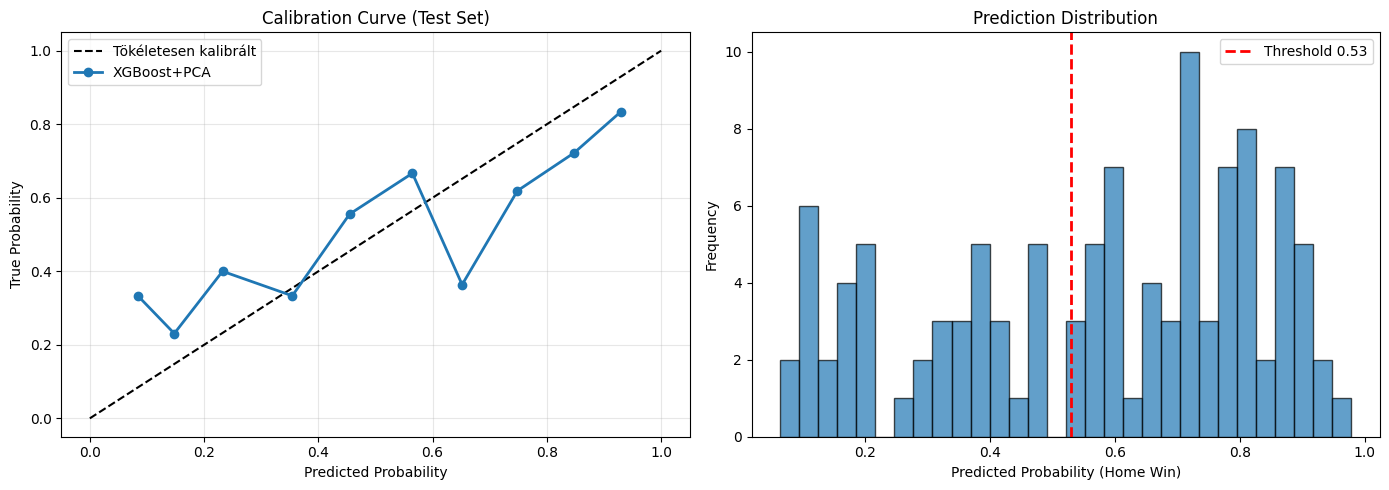


=== THRESHOLD SWEEP ANALÍZIS ===



C:\Users\Adam\AppData\Local\Temp\ipykernel_12280\3865275652.py:187: FutureWarning: The behavior of Series.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  best_roi_thresh = thresh_df.loc[thresh_df['roi'].idxmax()]


KeyError: nan

In [10]:
# XGBoost + PCA deep dive

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from xgboost import XGBClassifier
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

# -------------------------------------------------------------------------
# 1) MODELL TRAINING ÉS PREDIKCIÓK GYŰJTÉSE
# -------------------------------------------------------------------------

print("="*70)
print("=== XGBOOST + PCA MODELL DEEP DIVE ANALÍZIS ===")
print("="*70)

df = df_enhanced.copy()
df.dropna(subset=["is_home_win"], inplace=True)

# Odds merge
df = df.merge(odds[['GAME_ID', 'odds_home', 'odds_away']], 
              left_on='game_id', right_on='GAME_ID', how='left')
df.drop(columns=['GAME_ID'], inplace=True)

df['implied_prob_home'] = 1 / df['odds_home']
df['implied_prob_away'] = 1 / df['odds_away']

y = df["is_home_win"]
feature_cols = [col for col in df.columns if col not in 
                ['is_home_win', 'game_id', 'odds_home', 'odds_away', 
                 'implied_prob_home', 'implied_prob_away', 'book_margin']]
X = df[feature_cols]

# Time-series split
split_idx = int(len(df) * 0.8)
X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

# Scaling + PCA
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA(n_components=0.90)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"\nPCA Components: {pca.n_components_} (90% variance)")

# Model training
xgb_model = XGBClassifier(
    n_estimators=200, learning_rate=0.05, max_depth=4,
    min_child_weight=5, gamma=1.0, subsample=0.8,
    colsample_bytree=0.8, reg_alpha=0.5, reg_lambda=2.0,
    eval_metric="logloss", use_label_encoder=False, random_state=42
)

xgb_model.fit(X_train_pca, y_train)

# Predictions
train_proba = xgb_model.predict_proba(X_train_pca)[:, 1]
test_proba = xgb_model.predict_proba(X_test_pca)[:, 1]

# Create results dataframe
test_results = df.iloc[split_idx:].copy()
test_results['pred_prob_home'] = test_proba
test_results['pred_prob_away'] = 1 - test_proba

# -------------------------------------------------------------------------
# 2) PCA KOMPONENS ANALÍZIS
# -------------------------------------------------------------------------

print(f"\n{'='*70}")
print("=== PCA KOMPONENS ELEMZÉS ===")
print(f"{'='*70}\n")

# Top 5 legfontosabb komponens
print(f"Első 5 komponens variance magyarázata:")
for i in range(min(5, pca.n_components_)):
    print(f"  PC{i+1}: {pca.explained_variance_ratio_[i]*100:.2f}%")

print(f"\nÖsszesen {pca.n_components_} komponens használva")
print(f"Teljes variance: {pca.explained_variance_ratio_.sum()*100:.2f}%")

# Top features az első 3 komponensben
print(f"\n--- Top 5 Feature Loadings (első 3 PC) ---")
components_df = pd.DataFrame(
    pca.components_[:3],
    columns=X.columns,
    index=[f'PC{i+1}' for i in range(3)]
)

for pc_name, pc_values in components_df.iterrows():
    top_features = pc_values.abs().nlargest(5)
    print(f"\n{pc_name}:")
    for feat, val in top_features.items():
        print(f"  {feat}: {val:.3f}")

# -------------------------------------------------------------------------
# 3) KALIBRÁCIÓ VIZSGÁLAT
# -------------------------------------------------------------------------

print(f"\n{'='*70}")
print("=== MODELL KALIBRÁCIÓ ===")
print(f"{'='*70}\n")

# Brier score
train_brier = brier_score_loss(y_train, train_proba)
test_brier = brier_score_loss(y_test, test_proba)

print(f"Brier Score (Train): {train_brier:.4f}")
print(f"Brier Score (Test):  {test_brier:.4f}")
print(f"Delta: {abs(test_brier - train_brier):.4f} {'(overfitting)' if test_brier > train_brier + 0.01 else '(jó generalizáció)'}")

# Calibration curve
prob_true, prob_pred = calibration_curve(y_test, test_proba, n_bins=10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Calibration plot
axes[0].plot([0, 1], [0, 1], 'k--', label='Tökéletesen kalibrált')
axes[0].plot(prob_pred, prob_true, 'o-', linewidth=2, label='XGBoost+PCA')
axes[0].set_xlabel('Predicted Probability')
axes[0].set_ylabel('True Probability')
axes[0].set_title('Calibration Curve (Test Set)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Probability distribution
axes[1].hist(test_proba, bins=30, alpha=0.7, edgecolor='black')
axes[1].axvline(0.53, color='red', linestyle='--', linewidth=2, label='Threshold 0.53')
axes[1].set_xlabel('Predicted Probability (Home Win)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Prediction Distribution')
axes[1].legend()

plt.tight_layout()
plt.show()

# -------------------------------------------------------------------------
# 4) THRESHOLD OPTIMALIZÁLÁS
# -------------------------------------------------------------------------

print(f"\n{'='*70}")
print("=== THRESHOLD SWEEP ANALÍZIS ===")
print(f"{'='*70}\n")

thresholds = np.arange(0.50, 0.70, 0.01)
threshold_results = []

for thresh in thresholds:
    bets = []
    
    for idx, row in test_results.iterrows():
        pred_home = row['pred_prob_home']
        pred_away = row['pred_prob_away']
        actual = row['is_home_win']
        odds_h = row['odds_home']
        odds_a = row['odds_away']
        
        if pred_home >= thresh:
            profit = (odds_h - 1) if actual == 1 else -1
            bets.append(profit)
        elif pred_away >= thresh:
            profit = (odds_a - 1) if actual == 0 else -1
            bets.append(profit)
    
    if len(bets) > 0:
        roi = (sum(bets) / len(bets)) * 100
        hit_rate = (sum([1 for b in bets if b > 0]) / len(bets)) * 100
        threshold_results.append({
            'threshold': thresh,
            'num_bets': len(bets),
            'total_profit': sum(bets),
            'roi': roi,
            'hit_rate': hit_rate,
            'avg_profit': sum(bets) / len(bets)
        })

thresh_df = pd.DataFrame(threshold_results)

# Best threshold
best_roi_thresh = thresh_df.loc[thresh_df['roi'].idxmax()]
best_profit_thresh = thresh_df.loc[thresh_df['total_profit'].idxmax()]

print(f"Legjobb ROI threshold: {best_roi_thresh['threshold']:.2f}")
print(f"  ROI: {best_roi_thresh['roi']:.2f}%")
print(f"  Bets: {best_roi_thresh['num_bets']:.0f}")
print(f"  Hit Rate: {best_roi_thresh['hit_rate']:.2f}%")

print(f"\nLegjobb Total Profit threshold: {best_profit_thresh['threshold']:.2f}")
print(f"  Profit: {best_profit_thresh['total_profit']:.2f} units")
print(f"  ROI: {best_profit_thresh['roi']:.2f}%")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

thresh_df.plot(x='threshold', y='roi', ax=axes[0,0], color='green', linewidth=2)
axes[0,0].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[0,0].set_ylabel('ROI (%)')
axes[0,0].set_title('ROI vs Threshold')
axes[0,0].grid(True, alpha=0.3)

thresh_df.plot(x='threshold', y='total_profit', ax=axes[0,1], color='blue', linewidth=2)
axes[0,1].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[0,1].set_ylabel('Total Profit (units)')
axes[0,1].set_title('Total Profit vs Threshold')
axes[0,1].grid(True, alpha=0.3)

thresh_df.plot(x='threshold', y='num_bets', ax=axes[1,0], color='orange', linewidth=2)
axes[1,0].set_ylabel('Number of Bets')
axes[1,0].set_title('Bet Volume vs Threshold')
axes[1,0].grid(True, alpha=0.3)

thresh_df.plot(x='threshold', y='hit_rate', ax=axes[1,1], color='purple', linewidth=2)
axes[1,1].axhline(50, color='red', linestyle='--', alpha=0.5, label='50% baseline')
axes[1,1].set_ylabel('Hit Rate (%)')
axes[1,1].set_title('Hit Rate vs Threshold')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# -------------------------------------------------------------------------
# 5) ODDS RANGE ANALÍZIS
# -------------------------------------------------------------------------

print(f"\n{'='*70}")
print("=== ODDS TARTOMÁNY TELJESÍTMÉNY ===")
print(f"{'='*70}\n")

# Odds bins
test_results['odds_bin'] = pd.cut(
    test_results.apply(lambda x: x['odds_home'] if x['pred_prob_home'] >= 0.53 
                       else x['odds_away'], axis=1),
    bins=[1.0, 1.5, 2.0, 2.5, 3.0, 10.0],
    labels=['1.0-1.5 (Heavy Fav)', '1.5-2.0 (Favorite)', 
            '2.0-2.5 (Slight Fav)', '2.5-3.0 (Underdog)', '3.0+ (Heavy Dog)']
)

odds_analysis = []
for odds_range in test_results['odds_bin'].dropna().unique():
    subset = test_results[test_results['odds_bin'] == odds_range]
    
    bets = []
    for idx, row in subset.iterrows():
        if row['pred_prob_home'] >= 0.53:
            profit = (row['odds_home'] - 1) if row['is_home_win'] == 1 else -1
            bets.append(profit)
        elif row['pred_prob_away'] >= 0.53:
            profit = (row['odds_away'] - 1) if row['is_home_win'] == 0 else -1
            bets.append(profit)
    
    if len(bets) > 0:
        odds_analysis.append({
            'odds_range': odds_range,
            'num_bets': len(bets),
            'total_profit': sum(bets),
            'roi': (sum(bets) / len(bets)) * 100,
            'hit_rate': (sum([1 for b in bets if b > 0]) / len(bets)) * 100
        })

odds_df = pd.DataFrame(odds_analysis)
print(odds_df.to_string(index=False))

# -------------------------------------------------------------------------
# 6) HOME vs AWAY TELJESÍTMÉNY
# -------------------------------------------------------------------------

print(f"\n{'='*70}")
print("=== HOME vs AWAY BETTING TELJESÍTMÉNY ===")
print(f"{'='*70}\n")

home_bets = []
away_bets = []

for idx, row in test_results.iterrows():
    if row['pred_prob_home'] >= 0.53:
        profit = (row['odds_home'] - 1) if row['is_home_win'] == 1 else -1
        home_bets.append(profit)
    elif row['pred_prob_away'] >= 0.53:
        profit = (row['odds_away'] - 1) if row['is_home_win'] == 0 else -1
        away_bets.append(profit)

print(f"HOME fogadások:")
print(f"  Bets: {len(home_bets)}")
print(f"  Total Profit: {sum(home_bets):.2f} units")
print(f"  ROI: {(sum(home_bets) / len(home_bets) * 100):.2f}%")
print(f"  Hit Rate: {(sum([1 for b in home_bets if b > 0]) / len(home_bets) * 100):.2f}%")

print(f"\nAWAY fogadások:")
print(f"  Bets: {len(away_bets)}")
print(f"  Total Profit: {sum(away_bets):.2f} units")
print(f"  ROI: {(sum(away_bets) / len(away_bets) * 100):.2f}%")
print(f"  Hit Rate: {(sum([1 for b in away_bets if b > 0]) / len(away_bets) * 100):.2f}%")

# -------------------------------------------------------------------------
# 7) IDŐBELI STABILITÁS & SZEZONALITÁS
# -------------------------------------------------------------------------

print(f"\n{'='*70}")
print("=== IDŐBELI TELJESÍTMÉNY ===")
print(f"{'='*70}\n")

# Rolling profit
test_results = test_results.sort_index()
cumulative_profit = []
rolling_roi = []
window = 20

for idx, row in test_results.iterrows():
    if row['pred_prob_home'] >= 0.53:
        profit = (row['odds_home'] - 1) if row['is_home_win'] == 1 else -1
    elif row['pred_prob_away'] >= 0.53:
        profit = (row['odds_away'] - 1) if row['is_home_win'] == 0 else -1
    else:
        profit = 0
    
    cumulative_profit.append(profit)

test_results['profit'] = cumulative_profit
test_results['cumulative_profit'] = test_results['profit'].cumsum()
test_results['rolling_roi_20'] = test_results['profit'].rolling(window=window).mean() * 100

# Stats
print(f"Időbeli statisztikák (20 meccs rolling window):")
print(f"  Max ROI (rolling): {test_results['rolling_roi_20'].max():.2f}%")
print(f"  Min ROI (rolling): {test_results['rolling_roi_20'].min():.2f}%")
print(f"  Volatility (ROI std): {test_results['rolling_roi_20'].std():.2f}%")

# Visualization
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

test_results['cumulative_profit'].plot(ax=axes[0], linewidth=2, color='blue')
axes[0].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[0].set_ylabel('Cumulative Profit (units)')
axes[0].set_title('Cumulative Profit Over Time')
axes[0].grid(True, alpha=0.3)

test_results['rolling_roi_20'].plot(ax=axes[1], linewidth=2, color='green')
axes[1].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[1].set_ylabel('ROI (%)')
axes[1].set_xlabel('Game Index')
axes[1].set_title('Rolling 20-Game ROI')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n{'='*70}")
print("=== ANALÍZIS BEFEJEZVE ===")
print(f"{'='*70}")